In [1]:
import h5py
import numpy as np
import os, glob

def deref_matlab_string_or_ref(f, item):
    # Case 1: HDF5 object reference
    if isinstance(item, h5py.Reference):
        return f[item]

    # Case 2: Dataset containing ASCII codes for string
    if isinstance(item, h5py.Dataset):
        data = item[()]  # get numpy array
        if np.issubdtype(data.dtype, np.integer):  # likely ASCII codes
            return ''.join(chr(c) for c in data.flatten())
        else:
            return data

    # Case 3: Numpy scalar or array
    if isinstance(item, np.ndarray) or np.isscalar(item):
        data = np.array(item)
        # If it's object reference inside an array
        if data.dtype == object and len(data) > 0 and isinstance(data[0], h5py.Reference):
            return f[data[0]]
        # If it's ASCII code array
        if np.issubdtype(data.dtype, np.integer):
            return ''.join(chr(c) for c in data.flatten())

    # Case 4: Something else (like already a string)
    if isinstance(item, (str, bytes)):
        return item.decode() if isinstance(item, bytes) else item

    # If none of the above
    return item


In [2]:
def load_rdata_field(f, field):
    """Load a field like 'ripples' or 'Rspikes' from q/Rdata robustly."""
    path = f['q']['Rdata'][field]
    data = np.array(path)

    results = []
    if data.dtype == object:  # multiple blocks
        for ref in data.flatten():
            if isinstance(ref, h5py.Reference):
                results.append(np.array(f[ref]))
    else:  # single dataset
        results.append(data)

    return results

In [3]:
import pandas as pd  
from sklearn import svm
from scipy.io import loadmat
from sklearn.svm import SVC
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import precision_recall_curve
from numpy import savetxt

import umap.umap_ as umap
import seaborn as sns

from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import os, glob
import collections
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import normalize
import h5py
import rippl_AI

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))


all_label = dict()
all_index= dict()
all_index_reverse= dict()
all_label_reverse= dict()


pt_ch_mapping ={
            # "EC130_513": [3],
            "EC130_200": [1,13],
            # "EC131_513": [273, 274, 275, 276, 282, 283, 284],
            # "EC131_513": [273, 275, 282, 284],
            "EC133_200": [282, 291, 292, 293],
            # "EC135_200": [303, 304],
            "EC135_200": [303],
            # "EC137_200": [258, 260, 271, 272],
            "EC137_200": [257, 258, 259, 269],
            # "EC143_513": [327, 329, 336, 338, 339],
            # "EC143_200": [329, 336, 338, 339],
            "EC143_200": [339],
            # "EC157_513": [323, 331, 332],
            # "EC157_200": [321, 323, 331, 332],
            "EC157_200": [321, 332, 333, 334],
            # "EC162_200": [85, 86, 99, 100],
            "EC162_200": [85, 86],
            "EC175_200": [301, 302],
            "EC183_200": [290],
            "EC186_200": [299, 300, 301],
            # "EC187_200": [309, 310, 311],
            "EC187_200": [309, 310],
            # "EC191_513": [2, 3, 4, 11, 12, 13, 65],
            # "EC191_200": [2, 3, 11, 12],
            "EC191_200": [2, 3, 4],
            "EC196_200": [300, 301, 303],
            # "EC219_513": [399, 400, 401, 402, 403],
            # "EC219_200": [399, 400, 401, 403],
            "EC219_200": [399, 400, 402, 403],
            "EC220_200": [53, 54, 76, 77],
            "EC221_200": [376, 377],
            # "EC222_513": [267,268,269,270,277],
            "EC222_200": [267, 268, 269, 270],
            }
pathname = '/scratch/dazhang/MATLAB/'
patient_block_map = collections.defaultdict(list)
for patient, channal_list in pt_ch_mapping.items():
    path = pathname + patient+'/'
    pt = patient[:-4]
    for cur_channel in channal_list:
        cur_channel = str(cur_channel)
        file_path = "/data/an/transformed/RR_h_referential_wSPKS/"+pt+"/AN/"+pt+"_AN_ch"+cur_channel+"_wSPKS.mat"
        block_names = []
        with h5py.File(file_path, "r") as f:
            blocks_refs = f['q']['blocks'][:]
            for i in range(blocks_refs.shape[1]):
                ref = blocks_refs[0,i]
                dataset = f[ref][:]          # dereference the object
                text = ''.join(chr(c) for c in dataset.flatten())  # convert char codes to string
                block_names.append(text)
            print("Raw data:", pt,  block_names)
            patient_block_map[pt] = block_names

        break
print("patient_block_map: ", patient_block_map)

all_res = []
start_end1 = []

empty_blocks = {"EC133_ch282":{'B67'},
 "EC137_ch259":{'B176'},
 "EC183_ch290":{'B132','B139','B142'},
# The followings are bad channels
 "EC220_ch55":{'B24','B27'},
 "EC220_ch75":{'B24','B27'},
 "EC221_ch375":{'B36','B47'},
 "EC221_ch374":{'B36','B47'},
 "EC196_ch302":{'B21'},
 "EC183_ch289":{'B132','B139','B142','B164'},
 "EC175_ch303":{'B11'},
 "EC157_ch322":{'B46'},
 "EC143_ch330":{'B35'},
 "EC137_ch260":{'B158','B185'},
 "EC137_ch259":{'B176'},
 "EC133_ch294":{'B60','B67'},
 "EC133_ch281":{'B60','B67'},
 "EC130_ch2":{'B8'},
 }



2026-09-10 23:10:06.735233: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-10 23:10:06.809154: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-09-10 23:10:06.809173: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-09-10 23:10:06.826614: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-10 23:10:07.259048: W tensorflow/stream_executor/platform/de

Raw data: EC130 ['B1', 'B6', 'B8']
Raw data: EC133 ['B60', 'B67']
Raw data: EC135 ['B5']
Raw data: EC137 ['B89', 'B99', 'B113', 'B124', 'B139', 'B158', 'B176', 'B185']
Raw data: EC143 ['B18', 'B34', 'B35']
Raw data: EC157 ['B12', 'B28', 'B31', 'B46']
Raw data: EC162 ['B1', 'B4', 'B13', 'B16']
Raw data: EC175 ['B11']
Raw data: EC183 ['B132', 'B139', 'B142', 'B164']
Raw data: EC186 ['B52', 'B56', 'B58']
Raw data: EC187 ['B27', 'B36', 'B39']
Raw data: EC191 ['B13']
Raw data: EC196 ['B21']
Raw data: EC219 ['B45', 'B48']
Raw data: EC220 ['B24', 'B27']
Raw data: EC221 ['B36', 'B47']
Raw data: EC222 ['B28', 'B31', 'B37', 'B40']
patient_block_map:  defaultdict(<class 'list'>, {'EC130': ['B1', 'B6', 'B8'], 'EC133': ['B60', 'B67'], 'EC135': ['B5'], 'EC137': ['B89', 'B99', 'B113', 'B124', 'B139', 'B158', 'B176', 'B185'], 'EC143': ['B18', 'B34', 'B35'], 'EC157': ['B12', 'B28', 'B31', 'B46'], 'EC162': ['B1', 'B4', 'B13', 'B16'], 'EC175': ['B11'], 'EC183': ['B132', 'B139', 'B142', 'B164'], 'EC186': 

In [4]:
file_list = []
all_specs = np.empty((0, 60))
for pt, blocks in patient_block_map.items():
    channel_list = pt_ch_mapping[pt+'_200']
    path = pathname + pt+'_200'+'/'
    
    ls_specs = np.empty((0, 60))
    all_file_list = glob.glob(os.path.join(path, '*.mat'))
    

    for each_channel in channel_list:
        cur_channel_list = []
        for filename in all_file_list:
            # print(pt, each_channel, filename)
            
            if  ("ls_ripple" not in filename) or  ("binsize_1_" in filename):
                continue
            with open(filename, 'r') as f: 
                
                if "Channel_"+str(each_channel)+"_" in filename and ("-empty" not in filename):
                    # print(filename)
                    specs = loadmat(filename)['ls_ripple']
                    # print(filename, specs.shape)
                    file_list.append(filename)
                    # print(specs.shape)
                    cur_channel_list.append(specs.shape[0])
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)

In [5]:
# file_list

In [6]:
name_all_list = []
start_all_list = []
patient_num = {
    "EC130_200": 1465,
    "EC133_200": 1220,
    "EC135_200": 344,
    "EC137_200": 7222,
    "EC143_200": 881,
    "EC157_200": 4747,
    "EC162_200": 2398,
    "EC175_200": 518,
    "EC183_200": 220,
    "EC186_200": 1710,
    "EC187_200": 1315,
    "EC191_200": 642,
    "EC196_200": 594,
    "EC219_200": 2015,
    "EC220_200": 2572,
    "EC221_200": 859,
    "EC222_200": 3125}
patient_start = {
    "EC130_200": 0,
    "EC133_200": 1465,
    "EC135_200": 2685,
    "EC137_200": 3029,
    "EC143_200": 10251,
    "EC157_200": 11132,
    "EC162_200": 15879,
    "EC175_200": 18277,
    "EC183_200": 18795,
    "EC186_200": 19015,
    "EC187_200": 20725,
    "EC191_200": 22040,
    "EC196_200": 22682,
    "EC219_200": 23276,
    "EC220_200": 25291,
    "EC221_200": 27863,
    "EC222_200": 28722,
    "end": 31847
}

for name, value in patient_num.items():
    # if name !="EC130_200" and name !="EC183_200":
    name_all_list.extend([name]*value)
    start_all_list.extend([patient_start[name]]*value)


# for name, value in patient_num.items():
#     if name !="EC130_200" and name !="EC183_200":
#         name_all_list.extend([name]*value)
#         start_all_list.extend([patient_start[name]]*value)

print(len(start_all_list), len(name_all_list))

31847 31847


In [7]:
# name_all_list[-10:]
# patient_block_map

In [8]:
file_list = []
all_specs = np.empty((0, 60))
for pt, blocks in patient_block_map.items():
    channel_list = pt_ch_mapping[pt+'_200']
    path = pathname + pt+'_200'+'/'
    
    ls_specs = np.empty((0, 60))
    # if pt == "EC130" or pt == "EC183":
    #     continue
    # all_file_list = glob.glob(os.path.join(path, '*.mat'))
    

    for each_channel in channel_list:

        file_path = "/data/an/transformed/RR_h_referential_wSPKS/"+ pt+"/AN/"+pt+"_AN_ch"+str(each_channel)+"_wSPKS.mat"
        
        with h5py.File(file_path, "r") as f:
            ripple_blocks = load_rdata_field(f, 'ripples')
            spike_blocks = load_rdata_field(f, 'Rspikes_THISchannel')
            print(f"{pt} {file_path} {len(blocks)}")  # Print file info once
            
            for ripples, spikes, each_block_name in zip(ripple_blocks, spike_blocks, blocks):
                if pt+'_ch'+str(each_channel) in empty_blocks and each_block_name in empty_blocks[pt+'_ch'+str(each_channel)]: 
                    continue
                else:
                    created_file = 'ls_ripple_'+pt+'_Channel_'+str(each_channel)+'_binsize_10_Block_'+str(blocks.index(each_block_name)+1)
                    # print("created_file ", created_file, blocks)
                    # ls_ripple_EC130_Channel_1_binsize_10_Block_1.mat
                if "Channel_"+str(each_channel)+"_" in created_file and ("-empty" not in created_file):
                    specs = loadmat(path+created_file)['ls_ripple']
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)
                raw_file = "/data/an/preprocessed/"+pt+"/"+pt+"_"+each_block_name+"/MAT files/"+pt+"_"+each_block_name+"_notched.mat"
                a = loadmat(raw_file)
                ripples = np.atleast_2d(ripples)
                spikes = np.atleast_1d(spikes)
                # Ripples: (1, 2) Spikes: (2,)
                if ripples.shape == (1, 2) and spikes.shape == (2,):
                    continue
                print("Ripples:", ripples.shape, "Spikes:", spikes.shape)
                train_LFPs=[]
                train_GTs=[]

                aa = np.hstack([a['d'][:, each_channel]])
                train_LFPs.append(aa[:, np.newaxis])
                bb =  np.vstack([ripples.T])
                # train_GTs.append(bb/512)
                averages_per_list = [int(np.mean(sublist)) for sublist in bb]
                print("Averages per sublist:", averages_per_list)

                architectures=['XGBOOST','SVM','LSTM','CNN1D','CNN2D']
                output=[]
                LFP_clean = np.nan_to_num(train_LFPs[0], nan=0.0, posinf=1e5, neginf=-1e5)
                # Option 2: Clip to float16 valid range if needed
                LFP_clean = np.clip(LFP_clean, -65000, 65000)

                for architecture in architectures:
                    channels=[0,-1,-1,-1,-1,-1,-1,-1]
                    SWR_prob, _ =rippl_AI.predict(LFP_clean,512,arch=architecture,model_number=1,channels=channels)
                    output.append(SWR_prob)
                ens_input=np.array(output).transpose()

                prob_ens=rippl_AI.predict_ens(ens_input)
                print(len(prob_ens),prob_ens.shape)
                all_res.extend(prob_ens.flatten()[averages_per_list])
    
    all_specs = np.concatenate([all_specs, ls_specs], axis=0)

EC130 /data/an/transformed/RR_h_referential_wSPKS/EC130/AN/EC130_AN_ch1_wSPKS.mat 3
Ripples: (2, 300) Spikes: (1, 300)
Averages per sublist: [914, 1125, 2130, 2308, 3292, 5249, 5331, 5424, 6196, 7778, 8435, 9682, 10257, 10488, 11581, 11836, 12193, 12271, 12313, 12413, 12508, 12633, 12981, 15222, 15531, 15700, 16862, 18804, 19152, 20392, 20831, 22074, 22216, 22481, 23342, 24104, 24262, 24580, 24718, 24832, 25221, 25262, 25335, 25444, 25531, 25822, 26003, 26279, 26868, 28295, 28774, 28939, 29232, 29416, 31230, 33377, 34584, 36193, 36629, 37810, 38889, 44730, 44884, 48851, 50205, 50961, 53531, 55156, 55398, 55555, 55663, 56553, 58008, 58206, 58420, 58929, 59007, 59379, 59491, 59885, 61160, 61431, 61920, 62236, 62631, 63690, 63745, 63861, 63911, 63977, 64115, 64218, 64773, 64973, 65862, 66025, 68599, 69191, 69372, 69956, 70058, 70148, 70240, 70408, 70461, 70577, 70711, 70793, 72623, 72847, 80091, 80860, 80981, 81589, 82641, 83646, 84988, 85978, 87278, 87408, 88243, 93047, 93164, 93270, 934

/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator _SigmoidCalibration from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator CalibratedClassifi

Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (194033, 8)
Normalizing data...
LSTM_1_Ch8_W60_Ts32_Bi0_L4_U11_E10_TB256.keras
190/190 [==============================] - 2s 8ms/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (194033, 8)
Normalizing data...
CNN1D_1_Ch8_W60_Ts16_OGmodel12
379/379 [==============================] - 0s 685us/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (194033, 8)
Normalizing data...
CNN2D_1_Ch8_W60_Ts40_OgModel
6064/6064 [==============================] - 2s 341us/step
194033 (194033, 1)
Ripples: (2, 115) Spikes: (1, 115)
Averages per sublist: [3519, 3732, 4730, 4768, 5880, 6507, 7330, 8168, 8900, 11243, 12238, 13847, 16068, 16909, 17041, 17941, 18628, 19036, 20031, 20173, 21094, 21727, 23037, 23811, 30286, 31460, 33083, 33873, 34018, 34440, 34660, 35159, 35284, 39929, 45408, 46371, 46944, 47664, 57485, 58483, 58

/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator _SigmoidCalibration from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator CalibratedClassifi

132/132 [==============================] - 2s 9ms/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (134646, 8)
Normalizing data...
CNN1D_1_Ch8_W60_Ts16_OGmodel12
263/263 [==============================] - 0s 721us/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (134646, 8)
Normalizing data...
CNN2D_1_Ch8_W60_Ts40_OgModel
4208/4208 [==============================] - 1s 338us/step
134646 (134646, 1)
Ripples: (2, 254) Spikes: (1, 254)
Averages per sublist: [697, 824, 1219, 1315, 1581, 1921, 2604, 2890, 2930, 3060, 3639, 3675, 4757, 5476, 6237, 6663, 7559, 7773, 7858, 7899, 8790, 8884, 8950, 9333, 9862, 13242, 13319, 13460, 13760, 13921, 14058, 14107, 14955, 15348, 15900, 16600, 16923, 17321, 17499, 17790, 18869, 19334, 20500, 21019, 21437, 21567, 21776, 21969, 22306, 22394, 22455, 22680, 22732, 22778, 23084, 23356, 24025, 24219, 24398, 24676, 24828, 25116, 25489, 25587, 25676, 25735, 25844, 26

...

171/171 [==============================] - 2s 9ms/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (174579, 8)
Normalizing data...
CNN1D_1_Ch8_W60_Ts16_OGmodel12
341/341 [==============================] - 0s 749us/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (174579, 8)
Normalizing data...
CNN2D_1_Ch8_W60_Ts40_OgModel
5456/5456 [==============================] - 2s 354us/step
174579 (174579, 1)
Ripples: (2, 160) Spikes: (1, 160)
Averages per sublist: [2006, 2650, 4192, 4336, 5610, 6434, 7210, 7253, 8410, 9368, 10419, 10469, 13381, 13440, 13792, 13933, 14032, 15386, 16206, 16570, 16871, 19470, 21937, 22387, 22474, 22519, 23243, 24113, 24915, 27551, 28077, 29738, 34155, 34967, 35427, 35893, 36089, 36284, 37090, 38059, 38165, 38996, 39698, 40279, 40714, 42376, 42739, 43362, 44765, 44895, 45059, 47942, 48746, 51183, 51366, 51401, 51463, 51511, 51849, 52440, 52478, 52630, 53696, 54602, 56532,

/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator _SigmoidCalibration from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator CalibratedClassifi

132/132 [==============================] - 2s 8ms/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (135158, 8)
Normalizing data...
CNN1D_1_Ch8_W60_Ts16_OGmodel12
264/264 [==============================] - 0s 764us/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (135158, 8)
Normalizing data...
CNN2D_1_Ch8_W60_Ts40_OgModel
4224/4224 [==============================] - 2s 372us/step
135158 (135158, 1)
Ripples: (2, 209) Spikes: (1, 209)
Averages per sublist: [2787, 3264, 4760, 5291, 5428, 5778, 6033, 6115, 6294, 6369, 6543, 7726, 7782, 8417, 10149, 11081, 11168, 11337, 12202, 12542, 12617, 13053, 13309, 13351, 13429, 15832, 16485, 17594, 17824, 18669, 21521, 22053, 22497, 22909, 23506, 24030, 24187, 25364, 27941, 29964, 30037, 30726, 31530, 31988, 33768, 33912, 34618, 36688, 37245, 37965, 38380, 38612, 39227, 39264, 39323, 39364, 39409, 39974, 42054, 45385, 45456, 45646, 45930, 46878, 47283, 476

/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator _SigmoidCalibration from version 1.2.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator CalibratedClassifi

153/153 [==============================] - 2s 8ms/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (156148, 8)
Normalizing data...
CNN1D_1_Ch8_W60_Ts16_OGmodel12
305/305 [==============================] - 0s 740us/step
Downsampling data from 512 to 512 Hz...
No downsaple is required
Shape of downsampled data: (156148, 8)
Normalizing data...
CNN2D_1_Ch8_W60_Ts40_OgModel
4880/4880 [==============================] - 2s 373us/step
156148 (156148, 1)


In [9]:
all_label = dict()
all_index= dict()
all_index_reverse= dict()
all_label_reverse= dict()



list1=[]
list2=[]
count = 0
tpr_list = []
fpr_list = []
tprs = []

# import json

# with open('patient_rename.txt') as f:
#     data = f.read()
# js = json.loads(data)
# print(js)


pt_ch_mapping ={
            # "EC130_513": [3],
            "EC130_200": [1,13],
            # "EC131_513": [273, 274, 275, 276, 282, 283, 284],
            # "EC131_513": [273, 275, 282, 284],
            "EC133_200": [282, 291, 292, 293],
            # "EC135_200": [303, 304],
            "EC135_200": [303],
            # "EC137_200": [258, 260, 271, 272],
            "EC137_200": [257, 258, 259, 269],
            # "EC143_513": [327, 329, 336, 338, 339],
            # "EC143_200": [329, 336, 338, 339],
            "EC143_200": [339],
            # "EC157_513": [323, 331, 332],
            # "EC157_200": [321, 323, 331, 332],
            "EC157_200": [321, 332, 333, 334],
            # "EC162_200": [85, 86, 99, 100],
            "EC162_200": [85, 86],
            "EC175_200": [301, 302],
            "EC183_200": [290],
            "EC186_200": [299, 300, 301],
            # "EC187_200": [309, 310, 311],
            "EC187_200": [309, 310],
            # "EC191_513": [2, 3, 4, 11, 12, 13, 65],
            # "EC191_200": [2, 3, 11, 12],
            "EC191_200": [2, 3, 4],
            "EC196_200": [300, 301, 303],
            # "EC219_513": [399, 400, 401, 402, 403],
            # "EC219_200": [399, 400, 401, 403],
            "EC219_200": [399, 400, 402, 403],
            "EC220_200": [53, 54, 76, 77],
            "EC221_200": [376, 377],
            # "EC222_513": [267,268,269,270,277],
            "EC222_200": [267, 268, 269, 270],
            }

patient_start = {
    "EC130_200": 0,
    "EC133_200": 1465,
    "EC135_200": 2685,
    "EC137_200": 3029,
    "EC143_200": 10251,
    "EC157_200": 11132,
    "EC162_200": 15879,
    "EC175_200": 18277,
    "EC183_200": 18795,
    "EC186_200": 19015,
    "EC187_200": 20725,
    "EC191_200": 22040,
    "EC196_200": 22682,
    "EC219_200": 23276,
    "EC220_200": 25291,
    "EC221_200": 27863,
    "EC222_200": 28722,
    "end": 31847
}
a = list(patient_start.values())[:-1]
b =  list(patient_start.values())[1:]
print([j-i for i, j in zip(a, b)])


patient_num = {
    "EC130_200": 1465,
    "EC133_200": 1220,
    "EC135_200": 344,
    "EC137_200": 7222,
    "EC143_200": 881,
    "EC157_200": 4747,
    "EC162_200": 2398,
    "EC175_200": 518,
    "EC183_200": 220,
    "EC186_200": 1710,
    "EC187_200": 1315,
    "EC191_200": 642,
    "EC196_200": 594,
    "EC219_200": 2015,
    "EC220_200": 2572,
    "EC221_200": 859,
    "EC222_200": 3125}



print(sum(list(patient_num.values())))
name_all_list = []
start_all_list = []

# for name, value in patient_num.items():
#     if name !="EC130_200" and name !="EC183_200":
#         name_all_list.extend([name]*value)
#         start_all_list.extend([patient_start[name]]*value)

for name, value in patient_num.items():
    # if name !="EC130_200" and name !="EC183_200":
    name_all_list.extend([name]*value)
    start_all_list.extend([patient_start[name]]*value)

print(len(start_all_list), len(name_all_list))

all_specs_label = []
all_specs = np.empty((0, 60))
# all_specs = np.empty((0, 31293))
file_list = []
# pathname = '/home/dazhang/'
pathname = '/scratch/dazhang/MATLAB/'
for patient, channal_list in pt_ch_mapping.items():
    # if patient[:-4] == "EC130" or patient[:-4] == "EC183":
    #     continue
    # if patient[:-4] != patient_of_interested:
    #      print("Only interested in patient: ", patient_of_interested)
    #      continue
    path = pathname + patient+'/'
    ls_specs = np.empty((0, 60))
    # ls_specs = np.empty((0, 31293))


    for cur_channel in channal_list:
        cur_channel = str(cur_channel) 
        cur_channel_list = []   
        # for filename in glob.glob(os.path.join(path, '*.mat')):
        for filename in sorted(glob.glob(os.path.join(path, '*.mat'))):
            
                # each_file = 'ls_ripple_'+str(patient)+'_Channel_' + str(cur_channel) + '_binsize_10_Block_'+str(blk)+'.mat'
            if  ("ls_ripple" not in filename) or  ("binsize_1_" in filename):
                continue
            with open(os.path.join(os.getcwd(), filename), 'r') as f: 
                if "Channel_"+str(cur_channel)+"_" in filename and ("-empty" not in filename):
                    # print(filename)
                    specs = loadmat(filename)['ls_ripple']
                    file_list.append(filename)
                    # print(specs.shape)
                    cur_channel_list.append(specs.shape[0])
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)

    all_specs_label = np.concatenate([all_specs_label, [patient]*len(ls_specs)])
    all_specs = np.concatenate([all_specs, ls_specs], axis=0)

print(all_specs.shape, all_specs_label)


file = open('spikes_file.txt','w')
for item in file_list:
	file.write(item+"\n")
file.close()



test_shape2 = []
all_spikes_label = np.empty((0, 1))
manual_label_spikes = list()
for each_file in file_list:

    patient_name = each_file.split("/")[-2]
    actural_file = each_file.split("/")[-1]
    actural_file_list = actural_file.split("_")
    # spike_file_name = patient_name+"/"+actural_file_list[0]+"_spikes_"+"_".join(actural_file_list[2:6])+"_1_"+"_".join(actural_file_list[7:])
    spike_file_name = pathname + patient_name+"/"+actural_file_list[0]+"_spikes_"+"_".join(actural_file_list[2:6])+"_1_"+"_".join(actural_file_list[7:])

    with open(spike_file_name, 'r') as f: 
        spikes = loadmat(spike_file_name)['ls_spikes']


    all_spikes_label = np.concatenate([all_spikes_label, spikes])
# print(all_spikes_label)

all_ripples = all_specs

print(all_ripples.shape)
print((all_spikes_label))

all_vectors = np.asarray(all_ripples)
embedding = umap.UMAP(n_components=2, min_dist=0.2, metric='euclidean', n_neighbors=15,random_state=42, n_epochs=100, verbose=True).fit_transform(all_vectors)



[1465, 1220, 344, 7222, 881, 4747, 2398, 518, 220, 1710, 1315, 642, 594, 2015, 2572, 859, 3125]
31847
31847 31847
(31847, 60) ['EC130_200' 'EC130_200' 'EC130_200' ... 'EC222_200' 'EC222_200'
 'EC222_200']
(31847, 60)
[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
UMAP(min_dist=0.2, n_epochs=100, n_jobs=1, random_state=42, verbose=True)
Thu Sep 10 23:30:11 2026 Construct fuzzy simplicial set
Thu Sep 10 23:30:11 2026 Finding Nearest Neighbors
Thu Sep 10 23:30:11 2026 Building RP forest with 14 trees


/home/dazhang/anaconda3/envs/new_klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Thu Sep 10 23:30:14 2026 NN descent for 15 iterations


	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Thu Sep 10 23:30:27 2026 Finished Nearest Neighbor Search
Thu Sep 10 23:30:29 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Thu Sep 10 23:30:35 2026 Finished embedding


In [10]:
def parse_line(line):
    line = line.strip()
    # remove numpy scalar wrappers
    line = (line.replace("np.int64(", "")
            .replace("np.int32(", "")
            .replace("np.float64(", "")
            .replace("np.float32(", "")
            .replace(")", ""))
    line = line.strip("[]")
    return [float(x.strip()) for x in line.split(",") if x.strip()]

In [11]:

#Import required module
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
#Initialize the class object
#930 is good



# red: spike
# blue: ripple
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap



each_pt_label = []
prob_list_all_patient = []
label_list_all_patient = []
spike_idx_list_all_patient = []
ripple_idx_list_all_patient = []
prob_values = []

total_idx_list = []
selected_global_idx = []
selected_patient_names = []
# total_idx_list.extend(spike_idx_list_all_patient)
# total_idx_list.extend(ripple_idx_list_all_patient)


for patient_of_interested, channal_list in pt_ch_mapping.items():
    if patient_of_interested[:-4] == "EC130" or patient_of_interested[:-4] == "EC183":
        continue
    # if patient_of_interested[:-4] != "EC186":
    #     continue

    prob_list_each_patient = []
    label_list_each_patient = []
    infile1 = open("true_label_file_exclude_"+str(patient_of_interested)+"_200.txt","r")
    infile2 = open("true_pred_file_exclude_"+str(patient_of_interested)+"_200.txt","r")

    spike_idx_file = open(str(patient_of_interested[:-4])+"_spikes_idx_correct_200.txt","r")
    ripple_idx_file  = open(str(patient_of_interested[:-4])+"_ripples_idx_correct_200.txt","r")
            
    
    for i, txt in enumerate(all_spikes_label):
        if all_specs_label[i] == patient_of_interested:

            for line1, line2 in zip(infile1, infile2):
                lines1_list = []
                lines2_list = []
                spike_list = []
                ripple_list = []
                
                # line1_each = line1[1:-2].split(',')
                # line2_each = line2[1:-2].split(',')
                line1_each = parse_line(line1)
                line2_each = parse_line(line2)
                
                for f, h in zip(line1_each, line2_each):
                    # print(patient_of_interested)
                    lines1_list.append(float(f))
                    lines2_list.append(float(h))

            for spike_idx in spike_idx_file: 
                if "," in spike_idx:
                    idx = spike_idx[1:-2].split(',')
                else:
                    idx = spike_idx[1:-2].split(' ')
                for i in idx:
                    spike_list.append(int(float(i)))

            for ripple_idx in ripple_idx_file: 
                if "," in ripple_idx:
                    idx = ripple_idx[1:-2].split(',')
                else:
                    idx = ripple_idx[1:-2].split(' ')
                # print(idx)
                for i in idx:
                    ripple_list.append(int(float(i)))

            
    print("Total length: "+patient_of_interested, len(lines2_list))
    label_list_each_patient.extend(lines1_list)
    prob_list_each_patient.extend(lines2_list)
    prob_list_all_patient.extend(prob_list_each_patient)
    label_list_all_patient.extend(label_list_each_patient)

    # spike_idx_list_all_patient.extend(spike_list)
    # ripple_idx_list_all_patient.extend(ripple_list)
    total_idx_list.extend(spike_list)
    total_idx_list.extend(ripple_list)

    # Convert this patient's local candidate indices to GLOBAL indices.
    # This avoids zip(total_idx_list, name_all_list, start_all_list) misalignment.
    local_idx_list = spike_list + ripple_list
    start_id = patient_start[patient_of_interested]
    patient_global_idx = [start_id + idx for idx in local_idx_list]
    selected_global_idx.extend(patient_global_idx)
    selected_patient_names.extend([patient_of_interested] * len(patient_global_idx))

print(total_idx_list)   
print(len(total_idx_list))
print(name_all_list)   
print(len(name_all_list))
print(start_all_list)   
print(len(start_all_list))
print(all_res)   
print(len(all_res))


# ============================================================
# Select all aligned arrays with ONE shared global index list
# ============================================================
selected_global_idx = np.asarray(selected_global_idx, dtype=int)
selected_patient_names = np.asarray(selected_patient_names)

print("Selected global indices:", len(selected_global_idx))
print("Unique selected indices:", len(np.unique(selected_global_idx)))

expected_selected_n = (
    patient_start["end"]
    - patient_num["EC130_200"]
    - patient_num["EC183_200"]
)

assert expected_selected_n == 30162
assert len(selected_global_idx) == expected_selected_n
assert len(np.unique(selected_global_idx)) == expected_selected_n
assert np.min(selected_global_idx) >= 0
assert np.max(selected_global_idx) < patient_start["end"]

all_res_array = np.asarray(all_res).reshape(-1)
assert len(embedding) == patient_start["end"]
assert len(all_vectors) == patient_start["end"]
assert len(all_res_array) == patient_start["end"]
assert len(name_all_list) == patient_start["end"]

each_pt_probs = all_res_array[selected_global_idx]
each_pt_embedding = embedding[selected_global_idx]
each_pt_vectors = all_vectors[selected_global_idx]
each_pt_name_list = np.asarray(name_all_list)[selected_global_idx]

# Verify patient labels agree with the indices constructed above.
assert np.array_equal(each_pt_name_list, selected_patient_names)

print(len(each_pt_probs))
print(len(each_pt_vectors))
print(each_pt_embedding.shape)
print(len(each_pt_name_list))

Total length: EC133_200 1220
Total length: EC135_200 344
Total length: EC137_200 7222
Total length: EC143_200 881
Total length: EC157_200 4747
Total length: EC162_200 2398
Total length: EC175_200 518
Total length: EC186_200 1710
Total length: EC187_200 1315
Total length: EC191_200 642
Total length: EC196_200 594
Total length: EC219_200 2015
Total length: EC220_200 2572
Total length: EC221_200 859
Total length: EC222_200 3125
[24, 28, 43, 44, 92, 93, 110, 117, 126, 130, 131, 153, 154, 157, 178, 179, 180, 185, 186, 195, 196, 212, 213, 218, 219, 224, 227, 239, 240, 253, 254, 255, 259, 261, 262, 286, 287, 292, 293, 325, 326, 332, 344, 345, 349, 352, 362, 363, 385, 387, 388, 389, 405, 406, 417, 434, 440, 441, 442, 448, 449, 450, 459, 460, 481, 482, 483, 484, 485, 486, 500, 501, 506, 507, 517, 531, 533, 537, 538, 543, 546, 558, 559, 578, 579, 585, 586, 588, 589, 590, 610, 614, 615, 650, 651, 668, 669, 678, 688, 689, 718, 743, 766, 780, 781, 782, 783, 784, 789, 790, 800, 812, 813, 814, 815, 8

In [12]:
print(all_specs.shape, len(all_res), len(each_pt_probs), len(np.asarray(all_ripples)),np.asarray(all_ripples).shape)

(31847, 60) 31847 30162 31847 (31847, 60)


In [13]:
import pickle

data = each_pt_probs  # list of 30162 floats
with open("ripple_AI_30162.pkl", "wb") as f:
    pickle.dump(data, f)

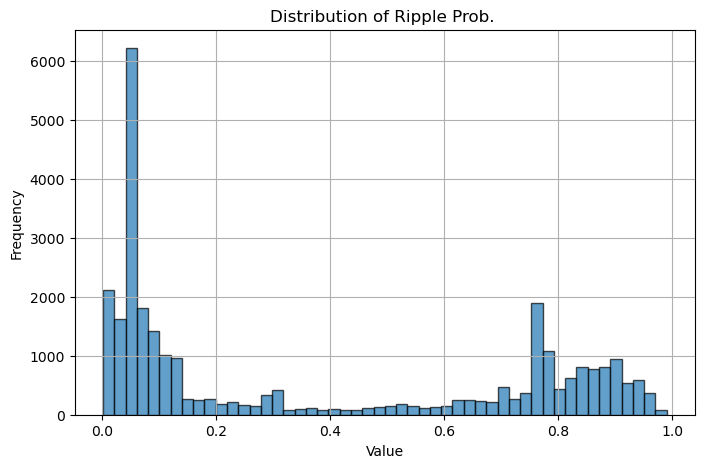

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(each_pt_probs, bins=50, alpha=0.7, edgecolor='black')
plt.title("Distribution of Ripple Prob. ")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [15]:
print(len(each_pt_probs))
print(len(all_vectors))

30162
31847


In [16]:
plasma = plt.cm.get_cmap('plasma')
values = np.linspace(0, 1, 100)
colors = plasma(values)
all_ripples = all_specs
all_vectors = np.asarray(all_ripples)
# embedding = umap.UMAP(n_components=2, min_dist=0.2, metric='euclidean',n_neighbors=15,random_state=42, n_epochs=100, verbose=True).fit_transform(all_vectors)
# IMPORTANT: do not refit UMAP here; keep the global embedding fitted on all_vectors in Cell 8
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

kmeans = KMeans(n_clusters = 5,random_state = 920, n_init=10)
kmeans_label = kmeans.fit(each_pt_embedding)

/tmp/ipykernel_1435676/1690002137.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma = plt.cm.get_cmap('plasma')


In [17]:
print(len(embedding))

31847


0.0 0.99


(-4.947333264350891,
 10.763229775428773,
 0.32402409911155694,
 13.104698640108108)

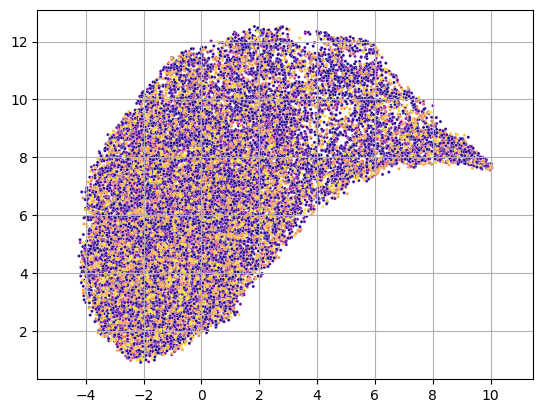

In [18]:
min_prob = round(min(each_pt_probs),2)
max_prob = round(max(each_pt_probs),2)
print(min_prob, max_prob)
prob_space = np.linspace(min_prob, max_prob, num=100)  # 100 points between 0.5 and 1

all_pt_color = []
prob_values = []
mapped_min = float('inf')
mapped_max = -float('inf')


for i, txt in enumerate(each_pt_probs):
    ripple_prob = each_pt_probs[i]
    neareast_prob = min(prob_space, key=lambda x: abs(x - ripple_prob))
    mapped_values = (neareast_prob - min_prob) / (max_prob - min_prob)

    mapped_min = min(mapped_min, mapped_values)
    mapped_max = max(mapped_max, mapped_values)
    
    prob_values.append(ripple_prob)
    cc = plasma(mapped_values)
    # print(cc)
    all_pt_color.append(cc[:-1])


ax = sns.scatterplot(x=each_pt_embedding[:,0], y=each_pt_embedding[:,1], c=all_pt_color, s=5.0)
ax.grid(True)
ax.axis('equal')

In [19]:
# total_idx_list = []
# # total_idx_list.extend(spike_idx_list_all_patient)
# # total_idx_list.extend(ripple_idx_list_all_patient)


# for patient_of_interested, channal_list in pt_ch_mapping.items():
#     if patient_of_interested[:-4] == "EC130" or patient_of_interested[:-4] == "EC183":
#         continue


#     spike_idx_file = open(str(patient_of_interested[:-4])+"_spikes_idx_correct_200.txt","r")
#     ripple_idx_file  = open(str(patient_of_interested[:-4])+"_ripples_idx_correct_200.txt","r")
            
    
#     for i, txt in enumerate(name_all_list):
#         if name_all_list[i] == patient_of_interested:
#             spike_list = []
#             ripple_list = []

#             for spike_idx in spike_idx_file: 
#                 if "," in spike_idx:
#                     idx = spike_idx[1:-2].split(',')
#                 else:
#                     idx = spike_idx[1:-2].split(' ')
#                 for i in idx:
#                     spike_list.append(int(float(i)))

#             for ripple_idx in ripple_idx_file: 
#                 if "," in ripple_idx:
#                     idx = ripple_idx[1:-2].split(',')
#                 else:
#                     idx = ripple_idx[1:-2].split(' ')
#                 # print(idx)
#                 for i in idx:
#                     ripple_list.append(int(float(i)))


#             total_idx_list.extend(spike_list)
#             total_idx_list.extend(ripple_list)

# print("Total length: ", len(total_idx_list))


# print(len(all_pt_color))
# all_pt_color = np.array(all_pt_color)
# print(all_pt_color.shape)
# each_pt_embedding = np.empty((0, 2))
# each_pt_coloring = np.empty((0, 3))
# each_pt_prob = []
# each_pt_name_list = []
# for idx,  name, start_id in zip(total_idx_list, name_all_list, start_all_list):
    
#     # all_pt_color.append(cc)

#     each_pt_embedding = np.concatenate([each_pt_embedding, embedding[start_id+idx,:].reshape(-1, 2)], axis=0)
#     each_pt_coloring = np.concatenate([each_pt_coloring, all_pt_color[start_id+idx,:].reshape(-1, 3)], axis=0)
#     each_pt_prob.append(all_res[start_id+idx])
#     each_pt_name_list.append(name_all_list[start_id+idx])


# print("Total length: ", len(each_pt_embedding))
# print("Total length: ", len(each_pt_coloring))
# print("Total length: ", len(each_pt_prob))
# print("Total length: ", len(each_pt_name_list))
# each_pt_prob = np.array(each_pt_prob)
    

In [20]:
# print(len(each_pt_embedding), len(each_pt_coloring), len(each_pt_prob))
# fig, ax = plt.subplots(dpi=300, figsize=(6,6))
# # ax = sns.scatterplot(x=each_pt_embedding[:,0], y=each_pt_embedding[:,1], c=all_pt_color, s=1.0)
# ax = sns.scatterplot(x=each_pt_embedding[:,0], y=each_pt_embedding[:,1], c=each_pt_coloring, s=5.0)
# ax.grid(True)
# ax.axis('equal')

# norm = plt.Normalize(mapped_min, mapped_max)
# sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)

# sm.set_array([])  # Only needed for older versions of Matplotlib
# # cbar = plt.colorbar(sm, ax=ax)
# # cbar.set_label('Probability of being a spike')
# cax = fig.add_axes([0.78, 0.70, 0.03, 0.15])

# cbar = plt.colorbar(sm, cax = cax, orientation='vertical')
# # cbar.set_label('Probability of being spikes')
# plt.show()

/tmp/ipykernel_1435676/1027875856.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma = plt.cm.get_cmap('plasma')


{0: 'blue', 1: 'red', 2: 'green', 3: 'cyan', 4: 'pink'}
30162 30162 30162
31847 31847 31847


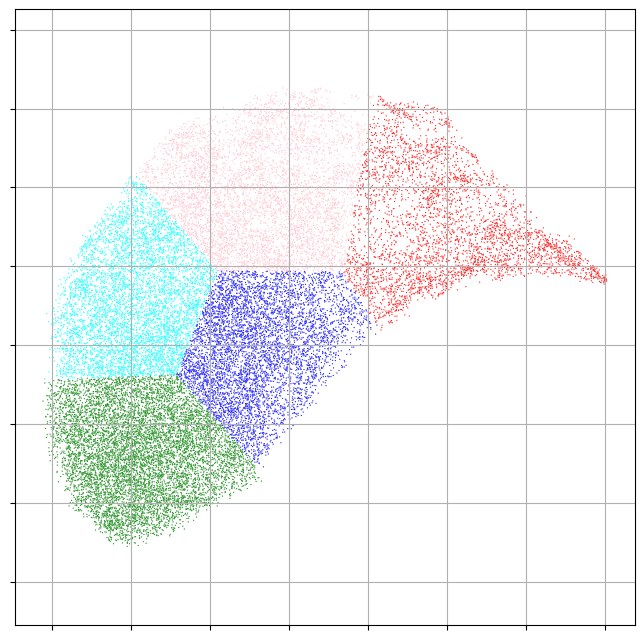

In [21]:
plasma = plt.cm.get_cmap('plasma')
values = np.linspace(0, 1, 100)
colors = plasma(values)
all_ripples = all_specs
all_vectors = np.asarray(all_ripples)
D_id_color = {}
D_id_color[0] = 'blue'
D_id_color[1] = 'red'
D_id_color[2] = 'green'
D_id_color[3] = 'cyan'
D_id_color[4] = 'pink'
print(D_id_color)

print(len(each_pt_embedding), len(each_pt_probs), len(each_pt_name_list))
print(len(embedding), len(all_res), len(name_all_list))
assert len(each_pt_embedding) == 30162
assert len(each_pt_probs) == 30162
assert len(each_pt_name_list) == 30162

# embedding = umap.UMAP(n_components=2, min_dist=0.2, metric='euclidean',n_neighbors=15,random_state=42, n_epochs=100, verbose=True).fit_transform(all_vectors)
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

kmeans = KMeans(n_clusters = 5,random_state = 920, n_init=10)
kmeans_label = kmeans.fit(each_pt_embedding)

fig, ax = plt.subplots(figsize=(8,8))
ax = sns.scatterplot(x=each_pt_embedding[:,0], y=each_pt_embedding[:,1], c=[D_id_color[f] for f in kmeans_label.labels_], s=0.8)
ax.figure.show()
ax.grid(True)
ax.axis('equal')
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.show()

In [22]:
print(embedding.shape)
print(D_id_color)
print(len(each_pt_probs))
print(len(kmeans_label.labels_))
each_pt_probs = np.asarray(each_pt_probs)


idx = np.where(kmeans_label.labels_ == 1)[0]
cluster_1_data = each_pt_probs[idx]
print(cluster_1_data, len(cluster_1_data), 1-np.mean(cluster_1_data))


idx = np.where(kmeans_label.labels_ == 4)[0]
cluster_4_data = each_pt_probs[idx]
print(cluster_4_data, len(cluster_4_data), 1-np.mean(cluster_4_data))


idx = np.where(kmeans_label.labels_ == 0)[0]
cluster_0_data = each_pt_probs[idx]
print(cluster_0_data, len(cluster_0_data), 1-np.mean(cluster_0_data))


idx = np.where(kmeans_label.labels_ == 3)[0]
cluster_3_data = each_pt_probs[idx]
print(cluster_3_data, len(cluster_3_data), 1-np.mean(cluster_3_data))


idx = np.where(kmeans_label.labels_ == 2)[0]
cluster_2_data = each_pt_probs[idx]
print(cluster_2_data, len(cluster_2_data), 1-np.mean(cluster_2_data))


(31847, 2)
{0: 'blue', 1: 'red', 2: 'green', 3: 'cyan', 4: 'pink'}
30162
30162
[0.01753006 0.06115855 0.88537157 ... 0.05488248 0.01572257 0.02896087] 4046 0.7036570310592651
[0.4001205  0.02234181 0.02152806 ... 0.01864583 0.2968474  0.07961626] 5214 0.6683005392551422
[0.7441189  0.85958374 0.03916322 ... 0.07235832 0.07165794 0.03540042] 6157 0.6209315657615662
[0.8651078  0.03033638 0.01242091 ... 0.28152162 0.05346531 0.44688493] 5947 0.6144687533378601
[0.02381134 0.11985329 0.01004807 ... 0.05220498 0.05476988 0.7718955 ] 8798 0.581495851278305


Cluster 1 : mean=0.4185, SEM=0.0039
Cluster 2 : mean=0.3855, SEM=0.0046
Cluster 3 : mean=0.3791, SEM=0.0045
Cluster 4 : mean=0.3317, SEM=0.0047
Cluster 5 : mean=0.2963, SEM=0.0052


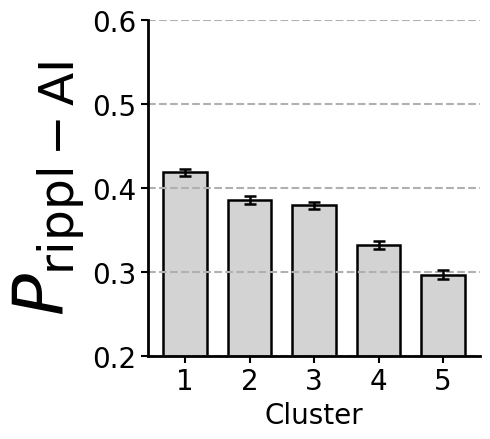

In [23]:
cluster_data = [
    np.asarray(cluster_2_data),
    np.asarray(cluster_3_data),
    np.asarray(cluster_0_data),
    np.asarray(cluster_4_data),
    np.asarray(cluster_1_data)
]

cluster_means = [
    np.nanmean(data)
    for data in cluster_data
]

cluster_sems = [
    np.nanstd(data, ddof=1) / np.sqrt(np.sum(~np.isnan(data)))
    for data in cluster_data
]
cluster_display_order = [2, 3, 0, 4, 1]
for bar_idx, (cluster_id, mean, sem) in enumerate(
    zip(cluster_display_order, cluster_means, cluster_sems),
    start=1
):
    print(
        f"Cluster {bar_idx} : "
        f"mean={mean:.4f}, "
        f"SEM={sem:.4f}"
    )


labels = ["1", "2", "3", "4", "5"]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(5, 4.5))

bars = ax.bar(
    x,
    cluster_means,
    width=0.68,
    color="lightgray",
    edgecolor="black",
    linewidth=1.8,
    yerr=cluster_sems,
    capsize=4,
    error_kw={
        "ecolor": "black",
        "elinewidth": 1.8,
        "capthick": 1.8
    }
)

# for bar, mean, sem in zip(bars, cluster_means, cluster_sems):
#     ax.text(
#         bar.get_x() + bar.get_width() / 2,
#         mean + sem + 0.012,
#         f"{mean:.3f} ± {sem:.3f}",
#         ha="center",
#         va="bottom",
#         fontsize=13,
#         fontweight="bold"
#     )

# Axis labels
ax.set_xlabel("Cluster", fontsize=20)
ax.set_ylabel(r"$P_{\mathrm{rippl-AI}}$", fontsize=50)

# Tick labels
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=20)
ax.tick_params(axis='y', labelsize=20)

# Y axis
ax.set_ylim(0.2, 0.6)

ax.grid(
    True,
    axis="y",
    linestyle="--",
    linewidth=1.5,
    alpha=1
)
# ax.grid(False)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Make axes thicker
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

# Tick marks
ax.tick_params(
    axis='both',
    width=1.5,
    length=5
)

plt.tight_layout()
plt.show()

In [28]:
min_vals = np.min(embedding, axis=0)
max_vals = np.max(embedding, axis=0)

# min_vals = [-4.1483297,  0.8951096] 
# max_vals = [ 9.943624, 12.604202]
# print(min_vals,max_vals )

min_vals = np.min(each_pt_embedding, axis=0)
max_vals = np.max(each_pt_embedding, axis=0)
print(min_vals, max_vals )


patient_label = {
"EC130_200":1,
"EC133_200" :2,
"EC135_200" :3,
"EC137_200": 4,
"EC143_200" :5,
"EC157_200" :6,
"EC162_200" :7,
"EC175_200" :8,
"EC183_200" :9,
"EC186_200" :10,
"EC187_200" :11,
"EC191_200" :12,
"EC196_200" :13,
"EC219_200" :14,
"EC220_200" :15,
"EC221_200":16,
"EC222_200" :17}


grid_size = (20, 20)  # Number of divisions in x and y dimensions
x_bins = np.linspace(min_vals[0], max_vals[0], grid_size[0] + 1)
y_bins = np.linspace(min_vals[1], max_vals[1], grid_size[1] + 1)
ratio = (max_vals[1] - min_vals[1])/(max_vals[0] - min_vals[0])

print(len(each_pt_embedding), len(each_pt_probs), len(each_pt_name_list))
print(len(embedding), len(all_res), len(name_all_list))
# assert len(each_pt_embedding) == len(each_pt_prob)
# assert len(each_pt_name_list) == len(each_pt_prob)



grid_entropy = dict()
grid_entropy_count = dict()
grid_entropy_patient_count = dict()
# for (x, y), prob, patient in zip(embedding, all_res, name_all_list):
# for (x, y), prob, patient in zip(embedding, each_pt_probs, each_pt_name_list):
for (x, y), prob, patient in zip(each_pt_embedding, each_pt_probs, each_pt_name_list):
    if patient == 'EC130_200' or patient == 'EC183_200':
        # print(patient)
        continue
    # print(prob)
    # x_idx = np.searchsorted(x_bins, x) - 1
    # y_idx = np.searchsorted(y_bins, y) - 1
    if not (min_vals[0] <= x <= max_vals[0] and min_vals[1] <= y <= max_vals[1]):
            continue

    x_idx = np.searchsorted(x_bins, x) - 1
    y_idx = np.searchsorted(y_bins, y) - 1

    # x_idx = min(x_idx, grid_size[0] - 1)
    # y_idx = min(y_idx, grid_size[1] - 1)

    if 0 <= x_idx < grid_size[0] and 0 <= y_idx < grid_size[1]:
        if (x_idx, y_idx) not in grid_entropy:
            grid_entropy[x_idx, y_idx] = 0.0
            grid_entropy_count[x_idx, y_idx] = 0
            grid_entropy_patient_count[(x_idx, y_idx)] = set()

        grid_entropy[x_idx, y_idx] += prob
        grid_entropy_count[x_idx, y_idx] += 1
        grid_entropy_patient_count[(x_idx, y_idx)].add(patient)
    # if (x_idx, y_idx) not in grid_entropy:
    #     grid_entropy[x_idx, y_idx] = 0.0
    #     grid_entropy_count[x_idx, y_idx] = 0
    #     grid_entropy_patient_count[(x_idx, y_idx)] = set()
    # # else:
    # grid_entropy[x_idx, y_idx] += prob
    # grid_entropy_count[x_idx, y_idx] += 1
    # grid_entropy_patient_count[(x_idx, y_idx)].add(patient)


print(grid_entropy)
print("length of grid entropy: ", grid_entropy_count)
print(sum(grid_entropy_count.values()))
grid_entropy_value = np.zeros(grid_size)
while_x = grid_size[0]
while_y = grid_size[1]

for i in range(while_x):
    for j in range(while_y):
        if (i, j) not in grid_entropy or (grid_entropy_count[i, j]==0):
            grid_entropy_value[i, j] = 0.0
        elif ((i, j) in grid_entropy) and ((len(grid_entropy_patient_count[(i, j)])<=1)):
            print("!!!!!!!!!!!!!!!", (i, j), len(grid_entropy_patient_count[(i, j)]))
            grid_entropy_value[i, j] = 0.0
        else:
            grid_entropy_value[i, j] = grid_entropy[i, j] / grid_entropy_count[i, j]



[-4.233217    0.90496385] [10.049113 12.523759]
30162 30162 30162
31847 31847 31847
{(15, 12): 50.166351264342666, (15, 15): 23.68867089552805, (18, 12): 40.97576859313995, (16, 13): 34.15398321952671, (17, 11): 6.803120232652873, (11, 11): 33.40994970826432, (16, 11): 10.762191887944937, (19, 11): 25.357820129953325, (14, 14): 19.410538444295526, (9, 14): 35.5794207053259, (10, 15): 23.28307710075751, (17, 12): 28.052106625866145, (16, 14): 28.49353709258139, (14, 16): 21.11038794135675, (11, 17): 21.791966852732003, (13, 15): 21.191581214312464, (14, 15): 31.70499402889982, (12, 17): 20.08710004738532, (16, 15): 5.380621719174087, (15, 17): 3.8802159731276333, (17, 13): 30.633977822493762, (13, 16): 25.143697396852076, (12, 19): 12.619698025286198, (14, 13): 24.14595481241122, (17, 14): 6.403540004044771, (14, 17): 18.308935226872563, (10, 10): 37.20942770084366, (18, 13): 16.5607388720382, (14, 18): 8.914707224350423, (3, 13): 65.484858231619, (15, 16): 18.424752976745367, (15, 14):

True grid probability min/max: 0.0960443081955115 0.5669266860544061
Normalized color range: 0.0 1.0


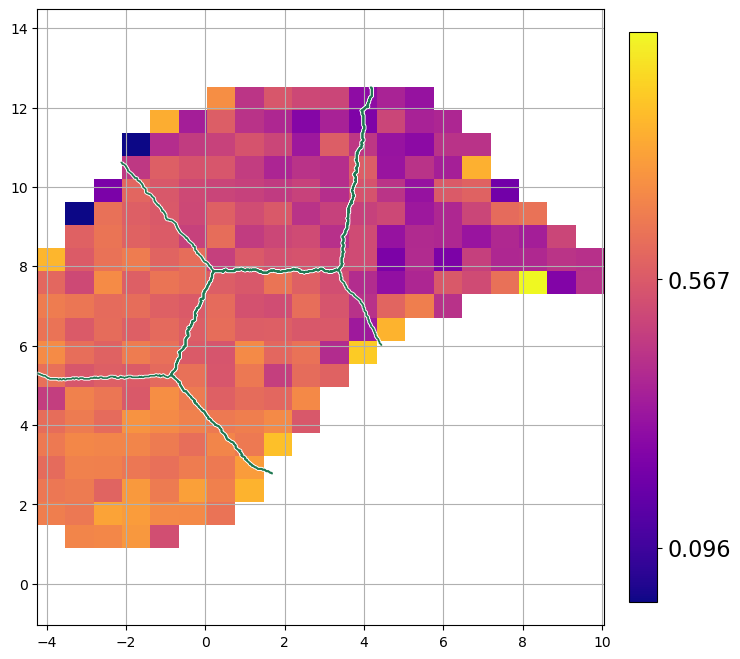

In [29]:


fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(True)
ax.axis('equal')
ax.set_facecolor('white')
cmap = plt.cm.plasma.copy()  # Copy the colormap to modify it
cmap.set_bad(color='white')  # Set masked values (0.0) to white

# Mask NaN values in the data to enforce white background
# Mask empty grids
masked_data = np.ma.masked_where(grid_entropy_value.T == 0.0,grid_entropy_value.T)

# Get min/max of the TRUE grid-average probabilities
mapped_min = np.min(masked_data)
mapped_max = np.max(masked_data)

print("True grid probability min/max:", mapped_min, mapped_max)

# Min-max normalize ONLY for color visualization
normalized_data = ((masked_data - mapped_min)/ (mapped_max - mapped_min))

print(
    "Normalized color range:",
    np.min(normalized_data),
    np.max(normalized_data)
)

cmap = plt.cm.plasma.copy()
cmap.set_bad(color='white')

c2 = ax.imshow(
    normalized_data,
    origin='lower',
    cmap=cmap,
    vmin=0,
    vmax=1,
    extent=[
        min_vals[0],
        max_vals[0],
        min_vals[1],
        max_vals[1]
    ]
)

# Normalized colorbar: 0–1
# cbar = plt.colorbar(
#     c2,
#     ax=ax,
#     orientation='vertical',
#     fraction=0.046,
#     pad=0.04
# )

# cbar.set_label("Normalized probability", fontsize=14)
# 
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial import cKDTree

# 如果你的 5-cluster 是在 embedding 上做的，就用 embedding
# 如果是在 embedding_bin 上做的，这里改成 embedding_bin
cluster_embedding = each_pt_embedding
cluster_labels = np.asarray(kmeans_label.labels_)

# 边界网格
xx, yy = np.meshgrid(
    np.linspace(min_vals[0], max_vals[0], 600),
    np.linspace(min_vals[1], max_vals[1], 600)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

# 用 KNN 重建 cluster 区域
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(cluster_embedding, cluster_labels)

Z = knn.predict(grid_points).reshape(xx.shape)

# 只保留靠近真实点云的边界，避免线拖太长
tree = cKDTree(cluster_embedding)
dist, _ = tree.query(grid_points, k=1)
dist = dist.reshape(xx.shape)

dist_thresh = 0.38
Z_masked = np.ma.masked_where(dist > dist_thresh, Z)

# 白色底线
ax.contour(
    xx, yy, Z_masked,
    levels=[0.5, 1.5, 2.5, 3.5],
    colors='white',
    linewidths=2.6,
    alpha=0.95,
    zorder=10
)

# 青色主线（和你图里这种感觉接近）
ax.contour(
    xx, yy, Z_masked,
    levels=[0.5, 1.5, 2.5, 3.5],
    colors='#1f7952',
    linewidths=1.2,
    alpha=1.0,
    zorder=11
) 


vmin = np.nanmin(masked_data)
vmax = np.nanmax(masked_data)

cbar = plt.colorbar(
    c2,
    ax=ax,
    orientation="vertical",
    fraction=0.046,
    pad=0.04
)

cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels([
    f"{vmin:.3f}",
    f"{vmax:.3f}"
])

cbar.ax.tick_params(labelsize=16)
plt.show()

# c2 = ax.imshow(masked_data, origin='lower', cmap=cmap, extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]])

# norm = plt.Normalize(mapped_min, mapped_max)
# sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
# sm.set_array([]) 
# cax = fig.add_axes([0.73, 0.20, 0.02, 0.17])
# cbar = plt.colorbar(sm, cax = cax, orientation='vertical')
# cbar.ax.set_yticklabels([]) 
# plt.show()

In [27]:
# name_all_list